# 🏆 Solution 2: YOLO + EasyOCR

**Category:** Modular Pipeline | **Best For:** Prototyping, beginners

```
Input → YOLOv8/v9 Detection → Crop → Preprocess → EasyOCR → Plate Text
```

In [10]:
!pip install ultralytics easyocr opencv-python matplotlib

zsh:1: /Users/mohitpaladiya/Desktop/project/Automatic License Plate Recognition /venv/bin/pip: bad interpreter: /Users/mohitpaladiya/Desktop/project/OpenALPR/venv/bin/python3.14: no such file or directory


In [23]:
from ultralytics import YOLO
import easyocr
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os, time

plt.rcParams['figure.figsize'] = (14, 8)
print('✅ Libraries loaded!')

✅ Libraries loaded!


In [24]:
# Load models
model = YOLO('../yolov9c.pt')  # or yolov8n.pt for speed
reader = easyocr.Reader(['en'], gpu=False)
print('✅ Models loaded!')

Using CPU. Note: This module is much faster with a GPU.


✅ Models loaded!


## Preprocessing Utilities

In [25]:
def preprocess_plate(plate_img):
    h, w = plate_img.shape[:2]
    if h < 50:
        scale = 100 / h
        plate_img = cv2.resize(plate_img, None, fx=scale, fy=scale)
    gray = cv2.cvtColor(plate_img, cv2.COLOR_BGR2GRAY) if len(plate_img.shape) == 3 else plate_img
    filtered = cv2.bilateralFilter(gray, 11, 17, 17)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(filtered)

def filter_plate_text(text):
    cleaned = ''.join(c for c in text.upper() if c.isalnum())
    return cleaned if len(cleaned) >= 3 else None

print('✅ Utilities ready!')

✅ Utilities ready!


## Detect & Read Plates

📸 Image: ../test/image-3.png

0: 480x640 1 car, 279.8ms
Speed: 2.8ms preprocess, 279.8ms inference, 0.5ms postprocess per image at shape (1, 3, 480, 640)
🔍 Objects detected: 1


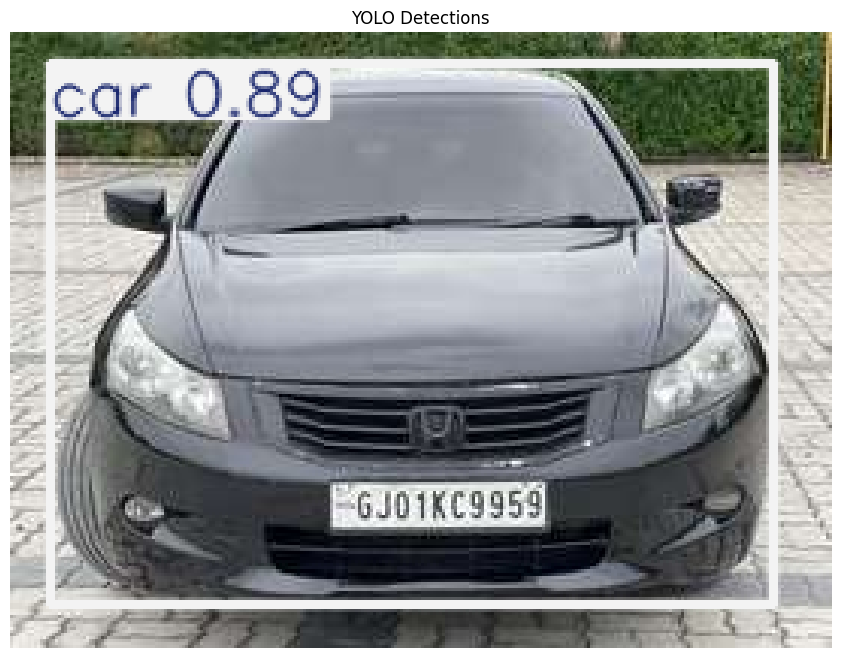

In [53]:
IMAGE_PATH = '../test/image-3.png'  # Update path

# Auto-find image
if not os.path.exists(IMAGE_PATH):
    for d in ['../images', '../test', '..']:
        if os.path.exists(d):
            for f in os.listdir(d):
                if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                    IMAGE_PATH = os.path.join(d, f)
                    break

img = cv2.imread(IMAGE_PATH)
print(f'📸 Image: {IMAGE_PATH}')

# YOLO detection
results = model(img)
print(f'🔍 Objects detected: {len(results[0].boxes)}')

# Show detections
annotated = results[0].plot()
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.title('YOLO Detections')
plt.axis('off')
plt.show()

In [56]:
ALLOWLIST = 'ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789'
detected_plates = []

for r in results:
    for i, box in enumerate(r.boxes.xyxy):
        x1, y1, x2, y2 = map(int, box)
        conf = float(r.boxes.conf[i])
        crop = img[y1:y2, x1:x2]
        if crop.size == 0: continue
        
        processed = preprocess_plate(crop)
        ocr_results = reader.readtext(processed, detail=1, allowlist=ALLOWLIST)
        
        for (bbox, text, ocr_conf) in ocr_results:
            cleaned = filter_plate_text(text)
            if cleaned:
                detected_plates.append({'text': cleaned, 'confidence': ocr_conf, 'bbox': (x1,y1,x2,y2)})
                print(f'  🚗 Plate: {cleaned} | Conf: {ocr_conf:.2f}')

print(f'\n🏁 Total plates: {len(detected_plates)}')

  🚗 Plate: GJO1KC9959 | Conf: 0.46

🏁 Total plates: 1


## Visualize Results

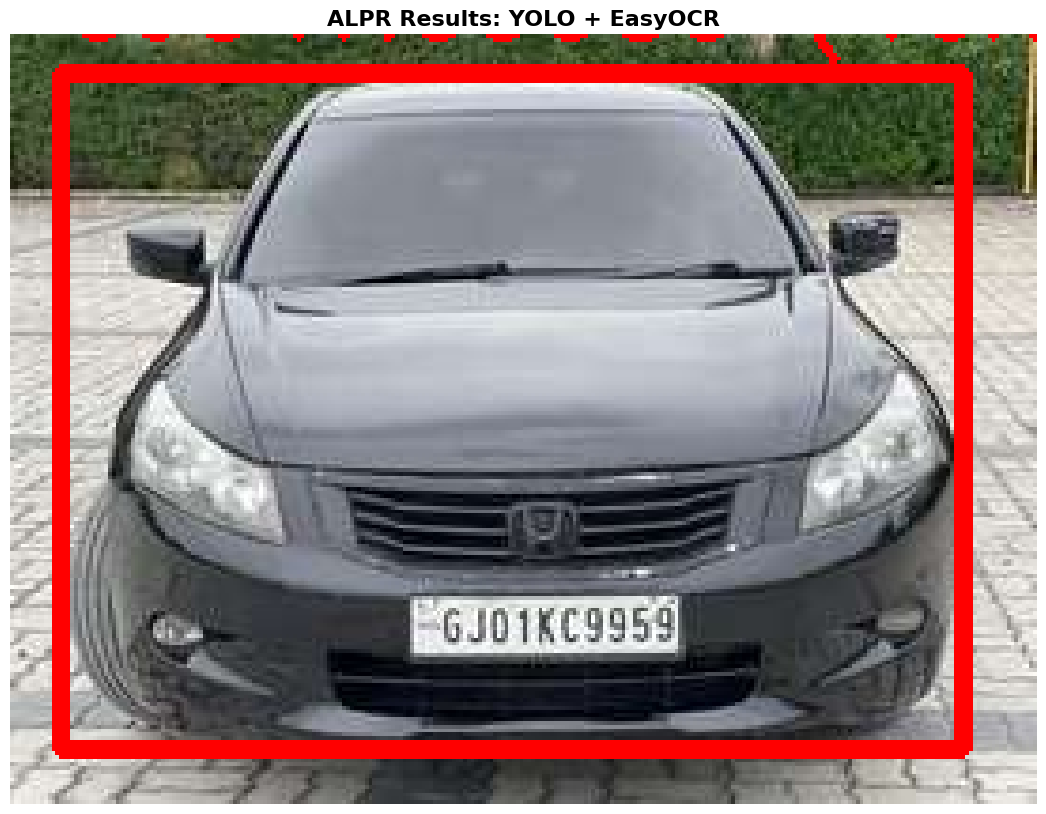

In [55]:
result_img = img.copy()
for p in detected_plates:
    x1,y1,x2,y2 = p['bbox']
    color = (0,255,0) if p['confidence']>=0.8 else (0,255,255) if p['confidence']>=0.5 else (0,0,255)
    cv2.rectangle(result_img, (x1,y1), (x2,y2), color, 3)
    label = f"{p['text']} ({p['confidence']:.0%})"
    cv2.putText(result_img, label, (x1,y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)

plt.figure(figsize=(16,10))
plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
plt.title('ALPR Results: YOLO + EasyOCR', fontsize=16, fontweight='bold')
plt.axis('off')
plt.show()

## Reusable Pipeline Class

In [38]:
class YOLOEasyOCR_ALPR:
    def __init__(self, yolo_model='yolov9c.pt', langs=['en'], gpu=False):
        self.model = YOLO(yolo_model)
        self.reader = easyocr.Reader(langs, gpu=gpu)
        self.allowlist = 'ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789'
    
    def preprocess(self, img):
        h, w = img.shape[:2]
        if h < 50: img = cv2.resize(img, None, fx=100/h, fy=100/h)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if len(img.shape)==3 else img
        return cv2.createCLAHE(2.0,(8,8)).apply(cv2.bilateralFilter(gray,11,17,17))
    
    def detect(self, image_path, conf=0.25):
        img = cv2.imread(image_path) if isinstance(image_path, str) else image_path
        plates = []
        for r in self.model(img, conf=conf):
            for i, box in enumerate(r.boxes.xyxy):
                x1,y1,x2,y2 = map(int, box)
                crop = img[y1:y2, x1:x2]
                if crop.size == 0: continue
                for _,text,c in self.reader.readtext(self.preprocess(crop), allowlist=self.allowlist):
                    t = ''.join(ch for ch in text.upper() if ch.isalnum())
                    if len(t)>=3: plates.append({'text':t,'confidence':c,'bbox':(x1,y1,x2,y2)})
        return plates

# Test
alpr = YOLOEasyOCR_ALPR('../yolov9c.pt')
for p in alpr.detect(IMAGE_PATH):
    print(f'  🚗 {p["text"]} ({p["confidence"]:.1%})')

Using CPU. Note: This module is much faster with a GPU.



0: 480x640 3 cars, 183.9ms
Speed: 1.5ms preprocess, 183.9ms inference, 0.5ms postprocess per image at shape (1, 3, 480, 640)
  🚗 UPSOAS4535 (83.2%)
  🚗 TERRANO (100.0%)


---
**➡️ For better OCR accuracy, try Notebook 03 (YOLO + PaddleOCR)**